# Sensitivity (Beta)

---

## Importing libraries

In [7]:
import yfinance as yf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

---

## Importing ticker data and basic cleaning

In [8]:
tickers = ['HDFCBANK.NS', 'ICICIBANK.NS', '^NSEBANK']
data = yf.download(tickers, period = "2y", auto_adjust=True)
data_dropped = data[~(data == 0).any(axis=1)].copy()
data_dropped = data_dropped[~data_dropped.isna().any(axis=1)].copy()
data_cleaned = data_dropped.copy()
data_cleaned['Volume'] = data_cleaned['Volume'].astype('float64').copy()

[*********************100%***********************]  3 of 3 completed


---

## Finding beta or sensitivity of the stock

### Getting % change

In [1]:
data_close = data_cleaned['Close'].copy() # Only require close data so doing that.
returns = data_close.pct_change().dropna() # pct_change gives % change with respect to the previous day.

NameError: name 'data_cleaned' is not defined

### Function to calculate beta

In [10]:
# Function for calculating beta
def beta(stock, index):
    matrix = np.cov(stock, index) # Covariance function tells how the variables vary together.
    
    # [ var(stock)  cov(stock, index)]
    # [cov(index, stock)    var(index)]
    # So the return matrix[0, 1] / matrix[1, 1] gives cov(stock, index) / var(index) = beta
    
    return matrix[0, 1] / matrix[1, 1]

In [11]:
# Getting beta for both using the function.
beta_hdfc = beta(returns["HDFCBANK.NS"], returns["^NSEBANK"])
beta_icici = beta(returns["ICICIBANK.NS"], returns["^NSEBANK"])

# Printing out 3 decimal beta of the stock. 
print(f"HDFC Bank Beta: {beta_hdfc:.3f}")
print(f"ICICI Bank Beta: {beta_icici:.3f}")

HDFC Bank Beta: 0.951
ICICI Bank Beta: 0.916


---

## Plotting beta for both the stocks

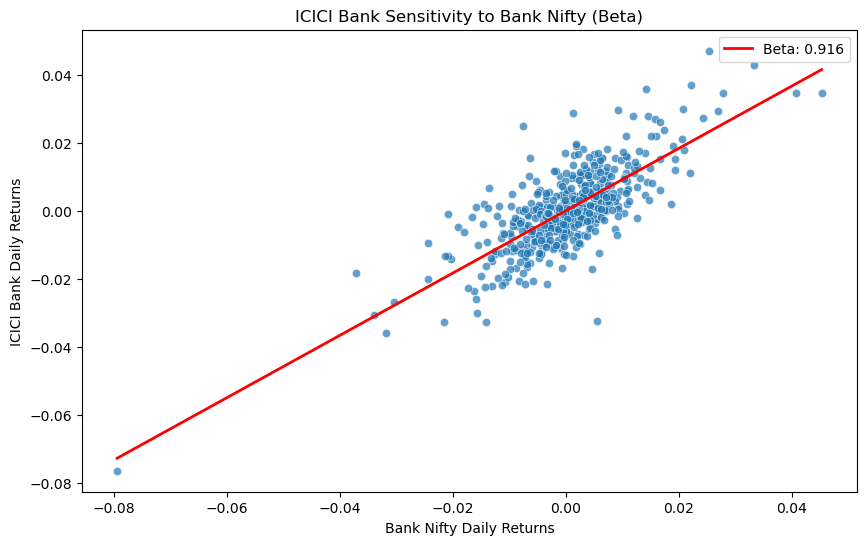

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="^NSEBANK", y="ICICIBANK.NS", linewidth=0.5, alpha=0.7, data=returns)

m, b = np.polyfit(returns['^NSEBANK'], returns['ICICIBANK.NS'], 1)
x = np.linspace(returns['^NSEBANK'].min(), returns['^NSEBANK'].max(), 100)
line = m*x + b

plt.plot(x, line, color='red', linewidth=2, label=f'Beta: {m:.3f}')

plt.title("ICICI Bank Sensitivity to Bank Nifty (Beta)")
plt.xlabel("Bank Nifty Daily Returns")
plt.ylabel("ICICI Bank Daily Returns")
plt.legend()
plt.show()

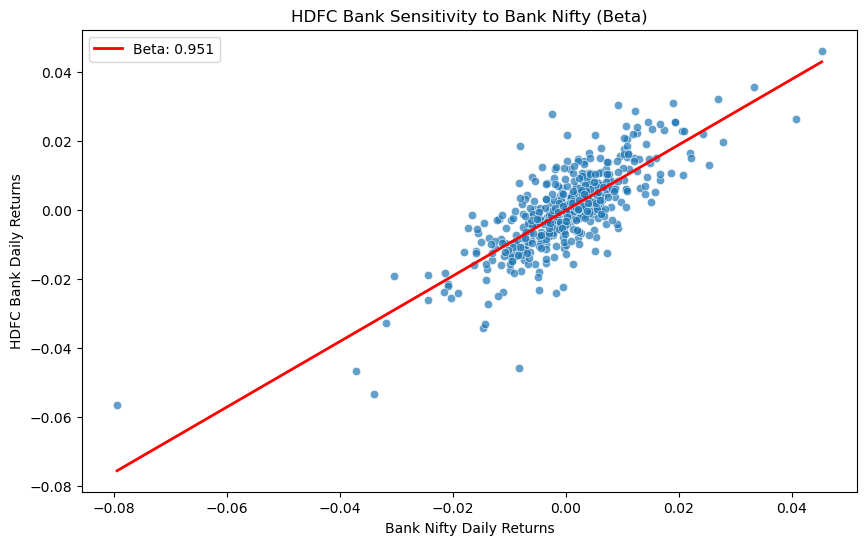

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="^NSEBANK", y="HDFCBANK.NS", linewidth=0.5, alpha=0.7, data=returns)

m, b = np.polyfit(returns['^NSEBANK'], returns['HDFCBANK.NS'], 1)
x = np.linspace(returns['^NSEBANK'].min(), returns['^NSEBANK'].max(), 100)
line = m*x + b

plt.plot(x, line, color='red', linewidth=2, label=f'Beta: {m:.3f}')

plt.title("HDFC Bank Sensitivity to Bank Nifty (Beta)")
plt.xlabel("Bank Nifty Daily Returns")
plt.ylabel("HDFC Bank Daily Returns")
plt.legend()
plt.show()

---